In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [5]:
print("Loading CIFAR-10 dataset...")

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [6]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
# Class names
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

print("Dataset loaded successfully")

Dataset loaded successfully


In [8]:
# Build CNN Model

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 18:15:58.162851: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training started...")

Training started...


In [10]:
# Train Model

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.3453 - loss: 1.7649 - val_accuracy: 0.5342 - val_loss: 1.2748
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5612 - loss: 1.2281 - val_accuracy: 0.5937 - val_loss: 1.1536
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6293 - loss: 1.0332 - val_accuracy: 0.6461 - val_loss: 1.0063
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6729 - loss: 0.9235 - val_accuracy: 0.6768 - val_loss: 0.9273
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7049 - loss: 0.8425 - val_accuracy: 0.6878 - val_loss: 0.9074
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7202 - loss: 0.7848 - val_accuracy: 0.6923 - val_loss: 0.8986
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7461 - loss: 0.7235 - val_accuracy: 0.7024 - val_loss: 0.8752
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7645 -

In [11]:
# Evaluate Model

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7206 - loss: 0.8209
Test Accuracy: 0.7132999897003174


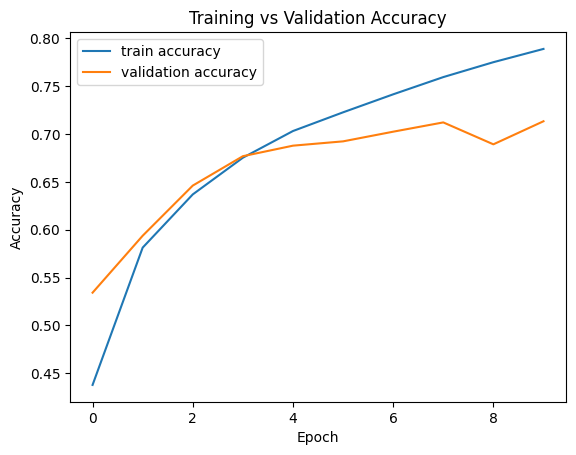

In [12]:
# Plot Training Performance

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


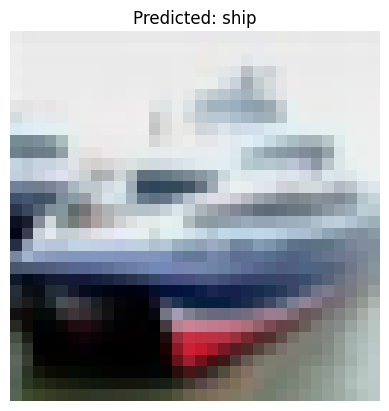

In [15]:
pred = model.predict(x_test)
idx = 1
predicted_class = np.argmax(pred[idx])
plt.imshow(x_test[idx])
plt.title("Predicted: "+class_names[predicted_class])
plt.axis("off")
plt.show()